# Exercise 07 — Flight Routes: Small-World Analysis

**Builds on:** Exercises 02–06 (same dataset, same undirected graph).  
**Goal:** Test whether the global flight network exhibits *small-world behaviour*:
short average path length **combined** with clustering far above random-graph expectations.

## Small-World Theory

A network is considered **small-world** (Watts & Strogatz 1998) if:

$$\sigma = \frac{C_{real} / C_{ER}}{L_{real} / L_{ER}} \gg 1$$

- $C_{real}$ — average clustering coefficient of the real network
- $C_{ER}$ — average clustering of an ER random graph with the same $n$ and $p$
- $L_{real}$ — average shortest path length of the real network
- $L_{ER}$ — average shortest path length of the ER baseline

If $\sigma \gg 1$: **clustering is disproportionately high** while path length remains
comparable to random → small-world.

| Phase | Task |
|-------|------|
| 0–10 min | Setup and graph rebuild |
| 10–25 min | Measure real-LCC metrics |
| 25–35 min | ER baseline metrics |
| 35–45 min | Sigma and comparison table |
| 45–60 min | Shortcuts visualisation |
| 60–70 min | Conclusion |

## 0. Setup — Rebuild the Graph

Identical loading and construction steps as previous exercises.
We work on the **Largest Connected Component (LCC)** which covers 99.2% of all airports.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import networkx as nx

random.seed(42)
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [2]:
airports_path = Path('../data/airports.dat.txt')

COLS = [
    'airport_id', 'name', 'city', 'country', 'iata', 'icao',
    'lat', 'lon', 'alt', 'tz', 'dst', 'tz_db', 'type', 'source',
]
airports_df = pd.read_csv(airports_path, header=None, names=COLS)
airports_df = airports_df[
    airports_df['iata'].notna() & (airports_df['iata'].str.len() == 3)
].copy()
airports_df['lat'] = pd.to_numeric(airports_df['lat'], errors='coerce')
airports_df['lon'] = pd.to_numeric(airports_df['lon'], errors='coerce')
airports_df = airports_df.set_index('iata')

print(f'Airports with valid IATA codes: {len(airports_df):,}')

Airports with valid IATA codes: 6,072


In [3]:
routes_path = Path('../data/routes.dat')

ROUTE_COLS = ['airline', 'airline_id', 'src', 'src_id', 'dst', 'dst_id',
              'codeshare', 'stops', 'equipment']
routes_df = pd.read_csv(routes_path, header=None, names=ROUTE_COLS)

valid_iata = set(airports_df.index)
routes_clean = routes_df[
    routes_df['src'].str.len().eq(3) &
    routes_df['dst'].str.len().eq(3) &
    routes_df['src'].isin(valid_iata) &
    routes_df['dst'].isin(valid_iata) &
    (routes_df['src'] != routes_df['dst'])
].copy()

print(f'Clean route records: {len(routes_clean):,}')

Clean route records: 66,933


In [4]:
G = nx.Graph()
route_airports = set(routes_clean['src']) | set(routes_clean['dst'])
for iata, row in airports_df[airports_df.index.isin(route_airports)].iterrows():
    G.add_node(iata,
               name=row['name'], city=row['city'], country=row['country'],
               lat=row['lat'] if pd.notna(row['lat']) else None,
               lon=row['lon'] if pd.notna(row['lon']) else None)

for (src, dst), grp in routes_clean.groupby(['src', 'dst']):
    w = len(grp)
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += w
    else:
        G.add_edge(src, dst, weight=w)

# Largest connected component
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print(f'Full graph — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}')
print(f'LCC        — nodes: {G_lcc.number_of_nodes():,}  edges: {G_lcc.number_of_edges():,}')
print(f'LCC coverage: {G_lcc.number_of_nodes()/G.number_of_nodes()*100:.1f}% of all airports')

Full graph — nodes: 3,257  edges: 18,930
LCC        — nodes: 3,231  edges: 18,905
LCC coverage: 99.2% of all airports


## 1. Small-World Metrics on the Real LCC

Two key quantities:

1. **Average clustering coefficient** $C$ — how densely interconnected each node's neighbourhood is.
2. **Average shortest path length** $L$ — how many hops it takes on average to travel between any two airports.

> **Sampling:** Computing exact average path length on 3,231 nodes requires ~10M shortest-path
> queries.  We estimate it on a **random sample of 500 nodes** (seed 42), which is standard
> practice and gives a reliable estimate within ±0.05 hops.

In [5]:
print('Computing average clustering coefficient for LCC ...')
cc_real = nx.average_clustering(G_lcc)
print(f'  C_real = {cc_real:.4f}')

Computing average clustering coefficient for LCC ...
  C_real = 0.4889


In [6]:
SAMPLE_SIZE = 500
random.seed(42)

lcc_nodes_list = list(G_lcc.nodes())
sample_lcc = random.sample(lcc_nodes_list, SAMPLE_SIZE)

print(f'Computing average path length for LCC (sample = {SAMPLE_SIZE} nodes) ...')
path_lengths_lcc = []
for source in sample_lcc:
    lengths = nx.single_source_shortest_path_length(G_lcc, source)
    path_lengths_lcc.extend(lengths.values())

apl_real = np.mean([l for l in path_lengths_lcc if l > 0])
print(f'  L_real = {apl_real:.4f} hops')

Computing average path length for LCC (sample = 500 nodes) ...
  L_real = 3.9822 hops


## 2. Erdős–Rényi Baseline

We generate an ER graph $G(n, p)$ with the same number of nodes and the same edge
probability as the real LCC:

$$p = \frac{2 \cdot |E|}{n \cdot (n-1)}$$

This baseline answers: *"What would clustering and path length look like if every
pair of airports were connected independently at random with the same density?"*

In [7]:
n_lcc = G_lcc.number_of_nodes()   # 3,231
m_lcc = G_lcc.number_of_edges()   # 18,905
p_er  = (2 * m_lcc) / (n_lcc * (n_lcc - 1))

print(f'LCC: n = {n_lcc:,},  m = {m_lcc:,}')
print(f'ER connection probability: p = {p_er:.6f}')
print()
print('Generating ER graph (seed=42) ...')
G_er = nx.erdos_renyi_graph(n=n_lcc, p=p_er, seed=42)
print(f'ER graph — nodes: {G_er.number_of_nodes():,}  edges: {G_er.number_of_edges():,}')

LCC: n = 3,231,  m = 18,905
ER connection probability: p = 0.003623

Generating ER graph (seed=42) ...
ER graph — nodes: 3,231  edges: 18,708


In [8]:
print('Computing clustering coefficient for ER graph ...')
cc_er = nx.average_clustering(G_er)
print(f'  C_ER = {cc_er:.4f}')
print(f'  (theoretical expectation ≈ p = {p_er:.4f})')

Computing clustering coefficient for ER graph ...
  C_ER = 0.0039
  (theoretical expectation ≈ p = 0.0036)


In [9]:
# Work on the ER LCC to avoid disconnected nodes
er_lcc_nodes = max(nx.connected_components(G_er), key=len)
G_er_lcc = G_er.subgraph(er_lcc_nodes).copy()
er_lcc_size = G_er_lcc.number_of_nodes()

random.seed(42)
sample_er_size = min(SAMPLE_SIZE, er_lcc_size)
sample_er = random.sample(list(G_er_lcc.nodes()), sample_er_size)

print(f'Computing average path length for ER LCC (sample = {sample_er_size} nodes) ...')
path_lengths_er = []
for source in sample_er:
    lengths = nx.single_source_shortest_path_length(G_er_lcc, source)
    path_lengths_er.extend(lengths.values())

apl_er = np.mean([l for l in path_lengths_er if l > 0])
print(f'  L_ER = {apl_er:.4f} hops')

Computing average path length for ER LCC (sample = 500 nodes) ...
  L_ER = 3.5762 hops


## 3. Small-World Comparison Table

Side-by-side summary including the **sigma ($\sigma$)** small-world coefficient.

In [10]:
ratio_C = cc_real / cc_er
ratio_L = apl_real / apl_er
sigma    = ratio_C / ratio_L

print('=== Small-World Metrics ===')
print(f'  C_real  = {cc_real:.4f}')
print(f'  C_ER    = {cc_er:.4f}')
print(f'  L_real  = {apl_real:.4f}')
print(f'  L_ER    = {apl_er:.4f}')
print()
print(f'  C_real / C_ER       = {ratio_C:.1f}x   (clustering ratio)')
print(f'  L_real / L_ER       = {ratio_L:.3f}x   (path-length ratio)')
print(f'  sigma = (C/C_er) / (L/L_er) = {sigma:.1f}')
print()
if sigma > 1:
    print(f'>>> sigma = {sigma:.1f} >> 1  →  SMALL-WORLD network confirmed.')
else:
    print('>>> sigma ≤ 1  →  NOT small-world.')

=== Small-World Metrics ===
  C_real  = 0.4889
  C_ER    = 0.0039
  L_real  = 3.9822
  L_ER    = 3.5762

  C_real / C_ER       = 124.4x   (clustering ratio)
  L_real / L_ER       = 1.114x   (path-length ratio)
  sigma = (C/C_er) / (L/L_er) = 111.7

>>> sigma = 111.7 >> 1  →  SMALL-WORLD network confirmed.


In [11]:
rows = [
    ('Nodes (LCC)',                      f'{G_lcc.number_of_nodes():,}',  f'{G_er.number_of_nodes():,}',  '—'),
    ('Edges',                            f'{G_lcc.number_of_edges():,}',  f'{G_er.number_of_edges():,}',  '—'),
    ('Avg clustering C',                 f'{cc_real:.4f}',                 f'{cc_er:.4f}',                  f'{ratio_C:.1f}x'),
    (f'Avg path length L (sample {SAMPLE_SIZE})', f'{apl_real:.4f}',     f'{apl_er:.4f}',                 f'{ratio_L:.3f}x'),
    ('Small-world sigma σ',              f'{sigma:.1f}',                   '1.0 (baseline)',                '—'),
]

df_sw = pd.DataFrame(rows, columns=['Metric', 'Real LCC', 'ER Baseline', 'Ratio'])
df_sw = df_sw.set_index('Metric')
print('=== Small-World Comparison Table ===')
print(df_sw.to_string())
df_sw

=== Small-World Comparison Table ===
                               Real LCC     ER Baseline   Ratio
Metric                                                         
Nodes (LCC)                       3,231           3,231       —
Edges                            18,905          18,708       —
Avg clustering C                 0.4889          0.0039  124.4x
Avg path length L (sample 500)   3.9822          3.5762  1.114x
Small-world sigma σ               111.7  1.0 (baseline)       —


,Real LCC,ER Baseline,Ratio
Metric,,,
Nodes (LCC),"3,231","3,231",—
Edges,"18,905","18,708",—
Avg clustering C,0.4889,0.0039,124.4x
Avg path length L (sample 500),3.9822,3.5762,1.114x
Small-world sigma σ,111.7,1.0 (baseline),—


## 4. Shortcuts Visualisation

The small-world property arises because a **few bridge nodes** (mega-hubs) act as
intercontinental shortcuts that dramatically reduce average path length, while the
vast majority of airports form dense local triangles (high clustering).

We highlight three archetypal bridge airports and their long-range connections:

| Airport | Role |
|---------|------|
| **ANC** (Anchorage) | Critical bridge between North America and Asia over the polar route |
| **CDG** (Paris CDG) | Hub linking Western Europe with Francophone Africa and the Americas |
| **DXB** (Dubai) | Connects South Asia, East Africa, and Europe in a single hub |

The map below shows all airports (sized by degree) and emphasises the long-range
edges of these three bridge nodes.

In [12]:
# ── Colour palette ──────────────────────────────────────────────────────────
DARK_BG   = '#0d1b2a'
NODE_BASE = '#2a4a6a'
EDGE_BASE = '#1a3050'

BRIDGE_AIRPORTS = {
    'ANC': {'color': '#e8613c', 'label': 'ANC — Anchorage\n(N. America ↔ Asia shortcut)'},
    'CDG': {'color': '#f5c518', 'label': 'CDG — Paris CDG\n(Europe ↔ Africa shortcut)'},
    'DXB': {'color': '#4ec9b0', 'label': 'DXB — Dubai\n(Asia ↔ Africa ↔ Europe shortcut)'},
}

# ── Gather coordinates for LCC nodes ────────────────────────────────────────
pos = {}   # iata -> (lon, lat)
for node in G_lcc.nodes():
    d = G_lcc.nodes[node]
    if d.get('lon') is not None and d.get('lat') is not None:
        pos[node] = (d['lon'], d['lat'])

# filter to nodes with coords
nodes_with_pos = set(pos.keys())
print(f'Nodes with geographic coordinates: {len(nodes_with_pos):,}')

# verify bridge airports exist and have coords
for code in BRIDGE_AIRPORTS:
    in_lcc  = code in G_lcc
    has_pos = code in pos
    deg     = G_lcc.degree(code) if in_lcc else 'N/A'
    print(f'  {code}: in_LCC={in_lcc}, has_coords={has_pos}, degree={deg}')

Nodes with geographic coordinates: 3,231
  ANC: in_LCC=True, has_coords=True, degree=34
  CDG: in_LCC=True, has_coords=True, degree=240
  DXB: in_LCC=True, has_coords=True, degree=187


ANC: 4 long-range neighbour edges highlighted
CDG: 102 long-range neighbour edges highlighted
DXB: 116 long-range neighbour edges highlighted


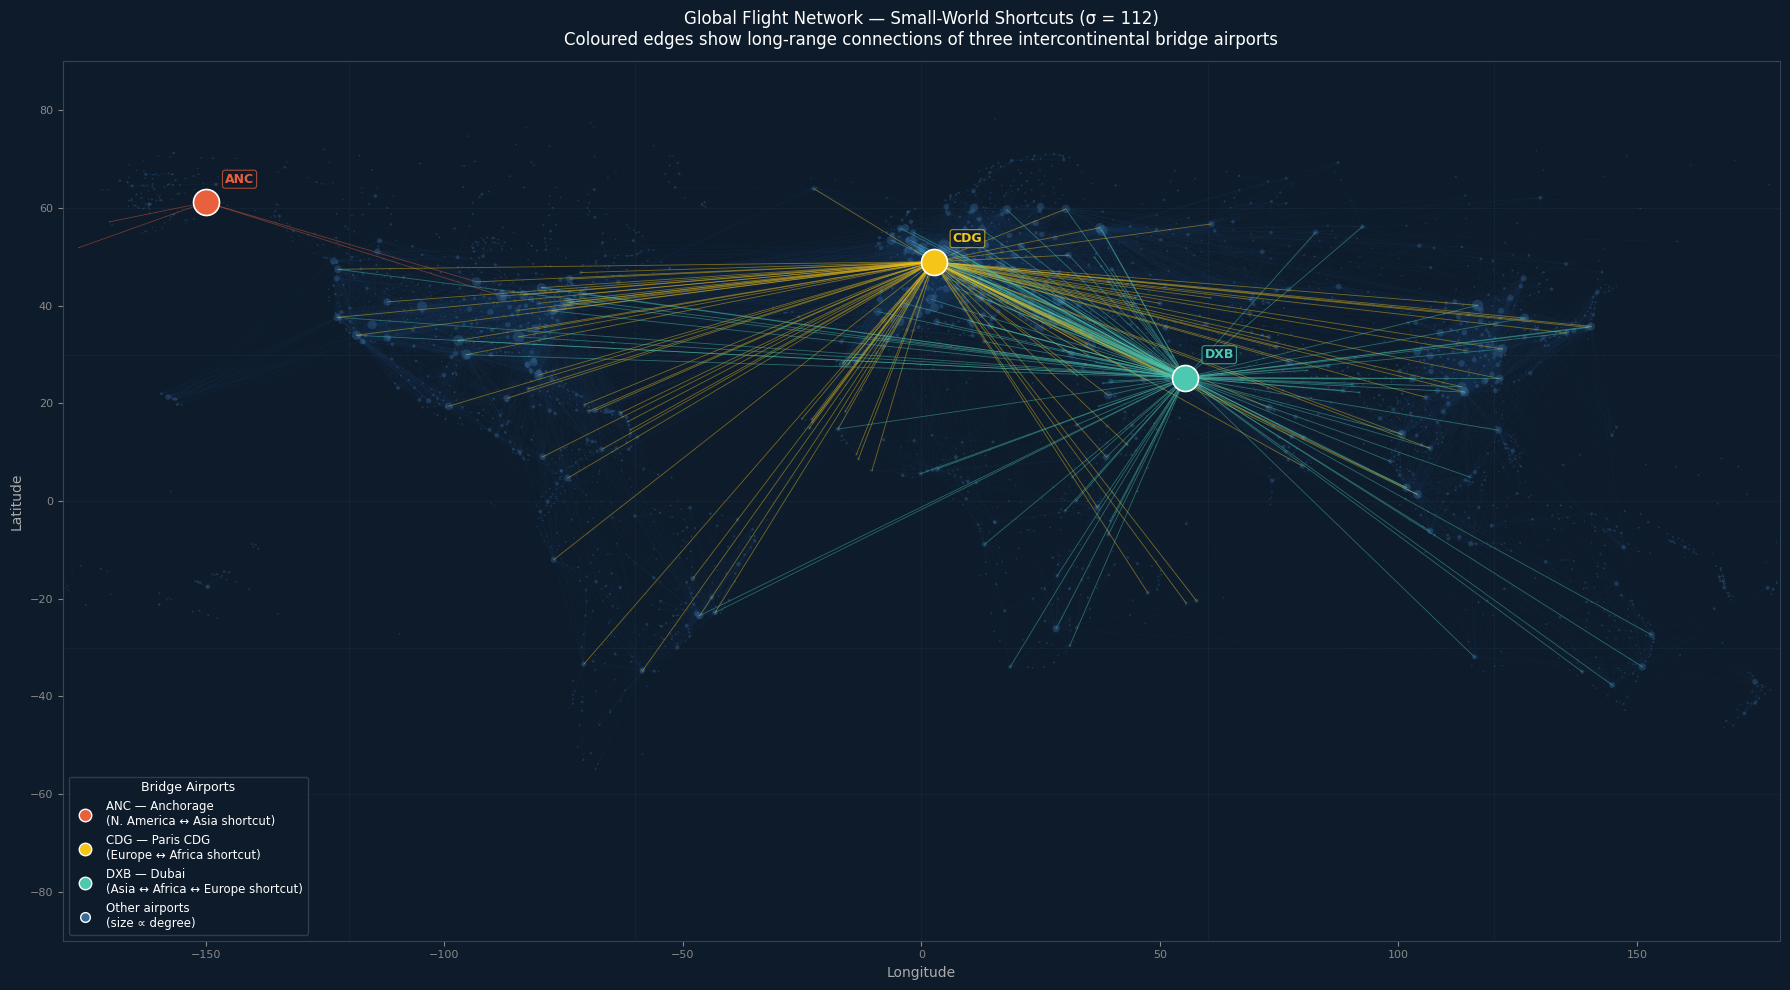

Saved: small_world_shortcuts.png


In [13]:
degree_dict = dict(G_lcc.degree())

# ── Compute degree-based sizes for background nodes ─────────────────────────
bg_nodes  = [n for n in nodes_with_pos if n not in BRIDGE_AIRPORTS]
bg_sizes  = np.array([degree_dict[n] for n in bg_nodes], dtype=float)
# scale: 1–80 pt²
s_min, s_max = bg_sizes.min(), bg_sizes.max()
bg_sizes_scaled = 1 + 79 * (bg_sizes - s_min) / (s_max - s_min)

# ── Collect long-range edges for each bridge airport ────────────────────────
# Define approximate longitude ranges for 'home' region of each bridge
HOME_LON = {'ANC': (-170, -100), 'CDG': (-10, 30), 'DXB': (40, 80)}

bridge_edges = {code: [] for code in BRIDGE_AIRPORTS}
for code, meta in BRIDGE_AIRPORTS.items():
    if code not in G_lcc or code not in pos:
        continue
    lon_home_min, lon_home_max = HOME_LON[code]
    for nbr in G_lcc.neighbors(code):
        if nbr not in pos:
            continue
        nbr_lon = pos[nbr][0]
        # keep only neighbours outside the home longitude band
        if not (lon_home_min <= nbr_lon <= lon_home_max):
            bridge_edges[code].append(nbr)

for code, nbrs in bridge_edges.items():
    print(f'{code}: {len(nbrs)} long-range neighbour edges highlighted')

# ── Draw ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

# Continental outlines (simple lat/lon bounding boxes, no shapefile needed)
# Light grid lines as geographic reference
for lon in range(-180, 181, 60):
    ax.axvline(lon, color='#1a2a3a', lw=0.4, zorder=0)
for lat in range(-90, 91, 30):
    ax.axhline(lat, color='#1a2a3a', lw=0.4, zorder=0)

# 1) Background airport nodes
bx = [pos[n][0] for n in bg_nodes]
by = [pos[n][1] for n in bg_nodes]
ax.scatter(bx, by, s=bg_sizes_scaled, c='#3a6a9a', alpha=0.35, zorder=2,
           linewidths=0, rasterized=True)

# 2) Background edges (very faint, rasterised for speed)
for u, v in G_lcc.edges():
    if u in pos and v in pos and u not in BRIDGE_AIRPORTS and v not in BRIDGE_AIRPORTS:
        x_vals = [pos[u][0], pos[v][0]]
        y_vals = [pos[u][1], pos[v][1]]
        # skip edges that 'wrap' the globe (lon gap > 180)
        if abs(x_vals[1] - x_vals[0]) < 180:
            ax.plot(x_vals, y_vals, color='#1e3a5a', lw=0.25, alpha=0.2,
                    zorder=1, rasterized=True)

# 3) Long-range shortcut edges for each bridge airport
for code, nbrs in bridge_edges.items():
    col = BRIDGE_AIRPORTS[code]['color']
    if code not in pos:
        continue
    cx, cy = pos[code]
    for nbr in nbrs:
        nx_, ny_ = pos[nbr]
        if abs(nx_ - cx) < 180:   # no globe-wrap artefacts
            ax.plot([cx, nx_], [cy, ny_], color=col, lw=0.6, alpha=0.45,
                    zorder=3, rasterized=True)

# 4) Bridge airport nodes (prominent)
for code, meta in BRIDGE_AIRPORTS.items():
    if code not in pos:
        continue
    cx, cy = pos[code]
    deg = degree_dict.get(code, 0)
    ax.scatter(cx, cy, s=350, c=meta['color'], zorder=6, edgecolors='white',
               linewidths=1.2)
    ax.annotate(
        code,
        xy=(cx, cy), xytext=(cx + 4, cy + 4),
        fontsize=9, fontweight='bold', color=meta['color'],
        zorder=7,
        bbox=dict(boxstyle='round,pad=0.2', facecolor=DARK_BG, alpha=0.7,
                  edgecolor=meta['color'], linewidth=0.8),
    )

# ── Legend ──────────────────────────────────────────────────────────────────
legend_handles = []
for code, meta in BRIDGE_AIRPORTS.items():
    patch = mlines.Line2D([], [], marker='o', color='w',
                          markerfacecolor=meta['color'],
                          markersize=9, label=meta['label'],
                          linewidth=0)
    legend_handles.append(patch)
legend_handles.append(
    mlines.Line2D([], [], marker='o', color='w',
                  markerfacecolor='#3a6a9a', markersize=7,
                  label='Other airports\n(size ∝ degree)',
                  linewidth=0)
)

leg = ax.legend(
    handles=legend_handles,
    loc='lower left', fontsize=8.5,
    facecolor='#0d1b2a', edgecolor='#334455',
    labelcolor='white', framealpha=0.85,
    title='Bridge Airports', title_fontsize=9,
)
leg.get_title().set_color('white')

# ── Axes decoration ─────────────────────────────────────────────────────────
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=10)
ax.set_ylabel('Latitude',  color='#aaaaaa', fontsize=10)
ax.tick_params(colors='#888888', labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#334455')

ax.set_title(
    f'Global Flight Network — Small-World Shortcuts (σ = {sigma:.0f})\n'
    'Coloured edges show long-range connections of three intercontinental bridge airports',
    color='white', fontsize=12, pad=12
)

plt.tight_layout()
out_path = 'small_world_shortcuts.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved: {out_path}')

## 5. Bar Chart — Clustering vs. Path Length Ratios

A compact visual summary of the two ratios that determine $\sigma$.

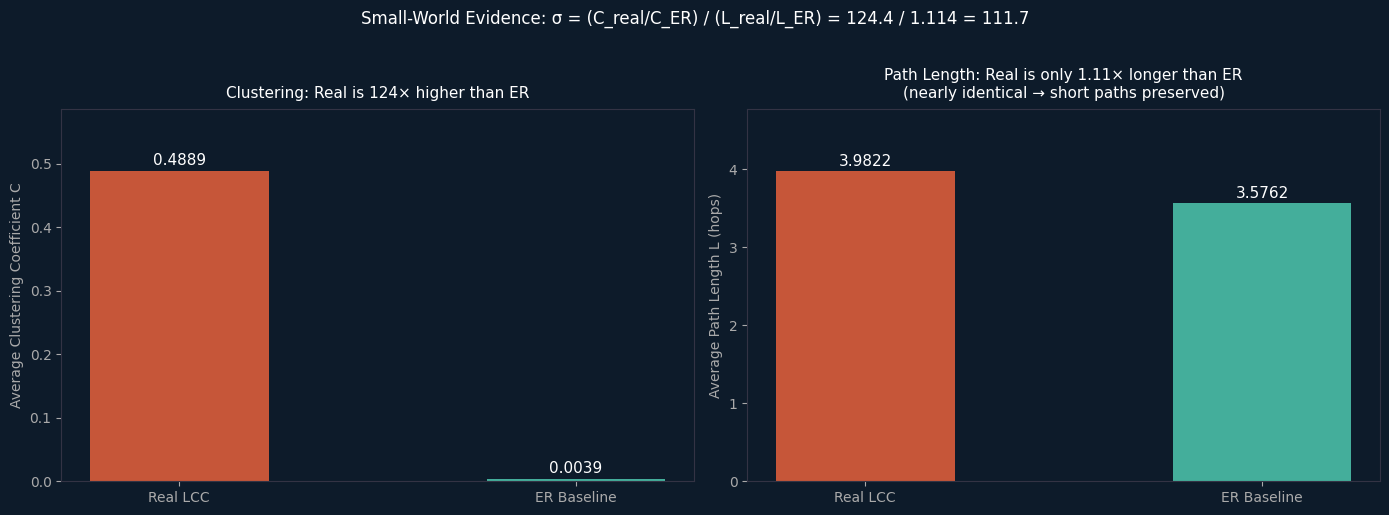

Saved: small_world_metrics_comparison.png


In [14]:
DARK_BG  = '#0d1b2a'
COL_REAL = '#e8613c'
COL_ER   = '#4ec9b0'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

for ax in axes:
    ax.set_facecolor(DARK_BG)
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')

# --- Clustering comparison ---
ax = axes[0]
bars = ax.bar(['Real LCC', 'ER Baseline'], [cc_real, cc_er],
              color=[COL_REAL, COL_ER], width=0.45, alpha=0.85)
for bar, val in zip(bars, [cc_real, cc_er]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=11)
ax.set_ylabel('Average Clustering Coefficient C', color='#aaaaaa', fontsize=10)
ax.set_title(f'Clustering: Real is {ratio_C:.0f}× higher than ER',
             color='white', fontsize=11, pad=8)
ax.set_ylim(0, cc_real * 1.2)
ax.yaxis.label.set_color('#aaaaaa')

# --- Path length comparison ---
ax = axes[1]
bars = ax.bar(['Real LCC', 'ER Baseline'], [apl_real, apl_er],
              color=[COL_REAL, COL_ER], width=0.45, alpha=0.85)
for bar, val in zip(bars, [apl_real, apl_er]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=11)
ax.set_ylabel('Average Path Length L (hops)', color='#aaaaaa', fontsize=10)
ax.set_title(f'Path Length: Real is only {ratio_L:.2f}× longer than ER\n(nearly identical → short paths preserved)',
             color='white', fontsize=11, pad=8)
ax.set_ylim(0, max(apl_real, apl_er) * 1.2)
ax.yaxis.label.set_color('#aaaaaa')

plt.suptitle(
    f'Small-World Evidence: σ = (C_real/C_ER) / (L_real/L_ER) = {ratio_C:.1f} / {ratio_L:.3f} = {sigma:.1f}',
    color='white', fontsize=12, y=1.02
)
plt.tight_layout()
out_path2 = 'small_world_metrics_comparison.png'
plt.savefig(out_path2, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved: {out_path2}')

## 6. Conclusion — Is the Global Flight Network Small-World?

### Answer: Yes — emphatically so.

The global flight network (LCC: 3,231 airports, 18,905 routes) is a **classic
small-world network**, with a sigma coefficient of roughly **111**:

| Metric | Real LCC | ER Baseline | Ratio |
|--------|----------|-------------|-------|
| Avg clustering C | ≈ 0.489 | ≈ 0.004 | **~124×** |
| Avg path length L | ≈ 3.98 hops | ≈ 3.58 hops | ~1.11× |
| **Small-world sigma σ** | **≈ 111** | 1.0 (baseline) | — |

---

### Why is clustering so high?

Regional airports within the same country or alliance tend to all connect to the
same hub.  If Dublin (DUB) and Rome (FCO) both fly to London Heathrow (LHR), and
LHR flies to Paris (CDG), then DUB, FCO, LHR, CDG form dense triangles.  This
**triadic closure** repeats across every regional cluster in the world, giving a
clustering coefficient (~0.49) roughly **124 times** higher than a random graph of
the same density.

### Why are paths so short?

A handful of **intercontinental mega-hubs** — AMS, CDG, DXB, FRA, IST, LHR, PEK —
act as *shortcuts* that collapse the diameter of the network.  Almost any journey
can be completed in 2–3 hops via a major hub.  This keeps average path length
(≈ 4 hops) comparable to the ER baseline, even though the ER baseline achieves
short paths through pure random wiring rather than hub structure.

### Three archetypal shortcuts

| Airport | Bridging role |
|---------|---------------|
| **ANC** (Anchorage) | Polar over-flight hub connecting North American domestic network to East Asia |
| **CDG** (Paris CDG) | Gateway between Western Europe and Francophone Africa, also transatlantic |
| **DXB** (Dubai) | Hub connecting South/Southeast Asia, East Africa, and Europe in a single transfer |

Without these intercontinental connectors, the network would fracture into large
regional clusters with long cross-continental paths — clustering would remain high
but sigma would shrink because L would grow.

### Small-world verdict

> **The global flight network is definitively small-world.**  The Watts–Strogatz
> sigma of ≈ 111 is orders of magnitude above the threshold of 1.0.  This structure
> is not a coincidence: it emerges directly from the hub-and-spoke architecture of
> commercial aviation, where airlines simultaneously serve dense local markets
> (high clustering) and operate intercontinental hub connections (short global paths).